In [173]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [174]:
mjf_dem = pd.read_csv("data/DEM EP NO2 O3 1025 0126.csv")
mjf_quant = pd.read_csv("data/MJF QAQ recalibrated historical data.csv")
dpw_quant = pd.read_csv("data/DPW quant.csv")
pema_quant = pd.read_csv("data/PEMA quant.csv")
pha_quant = pd.read_csv("data/PHA quant.csv")

## MJF DEM cleanup

In [175]:
mjf_dem.head()

,datetime EST,NO2,O3
0,10/1/25,4.3,20.5
1,10/1/25 1:00,3.4,21.0
2,10/1/25 2:00,2.5,23.0
3,10/1/25 3:00,2.2,23.8
4,10/1/25 4:00,2.9,22.4


In [176]:
mjf_dem = mjf_dem.rename(columns={"datetime EST": "datetime_est"})
mjf_dem["datetime_est"] = mjf_dem["datetime_est"].apply(
    lambda x: x + " 00:00" if len(x.split()) == 1 else x
)
mjf_dem["datetime_est"] = pd.to_datetime(mjf_dem["datetime_est"], format="%m/%d/%y %H:%M")
mjf_dem["datetime_est"] = pd.to_datetime(mjf_dem["datetime_est"], format="%m/%d/%y %H:%M", errors ="coerce")

mjf_dem.head()

,datetime_est,NO2,O3
0,2025-10-01 00:00:00,4.3,20.5
1,2025-10-01 01:00:00,3.4,21.0
2,2025-10-01 02:00:00,2.5,23.0
3,2025-10-01 03:00:00,2.2,23.8
4,2025-10-01 04:00:00,2.9,22.4


In [177]:
start_date = pd.to_datetime("10/12/25", format="%m/%d/%y")
end_date = pd.to_datetime("1/28/26", format="%m/%d/%y")

mjf_dem = mjf_dem[(mjf_dem["datetime_est"] >= start_date) & (mjf_dem["datetime_est"] <= end_date)]
mjf_dem.columns = mjf_dem.columns.str.lower()
mjf_dem = mjf_dem.dropna(subset=["no2", "o3"])

print(mjf_dem.head())
print(mjf_dem.tail())
mjf_dem.to_csv("data/MJF DEM cleaned.csv")

           datetime_est  no2    o3
239 2025-10-12 00:00:00  2.3  19.0
240 2025-10-12 01:00:00  2.0  21.2
241 2025-10-12 02:00:00  2.3  21.0
242 2025-10-12 03:00:00  1.7  23.0
243 2025-10-12 04:00:00  1.7  23.7
            datetime_est  no2    o3
2527 2026-01-27 20:00:00  7.4  37.9
2528 2026-01-27 21:00:00  8.2  36.7
2529 2026-01-27 22:00:00  9.0  35.6
2530 2026-01-27 23:00:00  9.7  34.5
2531 2026-01-28 00:00:00  8.5  34.9


## MJF quant cleanup

In [178]:
mjf_quant.head()

,timestamp_local,co,no,no2,o3,sn
0,2025-08-28 14:16:12.000,13567.516220,325.661007,-5.594733,235.480795,MOD-00809
1,2025-08-28 14:17:12.000,13568.115725,261.461897,-5.594733,214.030878,MOD-00809
2,2025-08-28 14:18:12.000,13568.996800,224.388608,-5.594733,195.068412,MOD-00809
3,2025-08-28 14:19:12.000,13570.134969,196.990455,-5.594732,-261.291336,MOD-00809
4,2025-08-28 14:20:12.000,13569.954212,177.957678,-5.594324,61.186989,MOD-00809


In [179]:
mjf_quant = mjf_quant.rename(columns={"timestamp_local": "datetime_est"})

mjf_quant["datetime_est"] = mjf_quant["datetime_est"].astype(str).str.replace(r"\.000$", "", regex=True)
mjf_quant["datetime_est"] = mjf_quant["datetime_est"].astype(str).str.replace(r"\.500$", "", regex=True)

mjf_quant["datetime_est"] = pd.to_datetime(mjf_quant["datetime_est"], format="%Y-%m-%d %H:%M:%S")

mjf_quant = mjf_quant[["datetime_est", "no2", "o3"]]

mjf_quant = mjf_quant.dropna(subset=["no2", "o3"])
mjf_quant = mjf_quant[(mjf_quant["no2"] >= 0) & (mjf_quant["o3"] >= 0)]

mjf_quant = mjf_quant.reset_index(drop=True)


mjf_quant_all = mjf_quant.copy()
mjf_quant_all.to_csv("data/MJF quant cleaned.csv")

mjf_quant_filtered = mjf_quant[(mjf_quant["datetime_est"] >= start_date) & (mjf_quant["datetime_est"] <= end_date)]

# print("All cleaned data:")
# print(mjf_quant_all.head())

# print("Filtered data for analysis:")
# print(mjf_quant_filtered.head())

mjf_quant = mjf_quant_filtered
mjf_quant.head()

,datetime_est,no2,o3
16321,2025-10-12 00:00:49,2.307181,46.179843
16322,2025-10-12 00:01:49,2.237972,46.774005
16323,2025-10-12 00:02:49,2.159700,46.904836
16324,2025-10-12 00:03:49,2.325370,46.650808
16325,2025-10-12 00:04:49,2.307181,45.723704


In [180]:
mjf_quant = mjf_quant.set_index("datetime_est")


mjf_quant = mjf_quant.resample("h").mean()

mjf_quant_hourly = mjf_quant.reset_index()


print(mjf_quant.head())

                          no2         o3
datetime_est                            
2025-10-12 00:00:00  2.103161  45.858176
2025-10-12 01:00:00  1.811379  46.046810
2025-10-12 02:00:00  1.598429  48.010886
2025-10-12 03:00:00  1.463875  47.698950
2025-10-12 04:00:00  1.118363  49.617327


## DPW quant cleaning

In [181]:
dpw_quant.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,pm1,...,no,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id
0,2026-02-28T23:59:28Z,620881804,2026-02-28T18:59:28Z,MOD-00811,82.2,3.9,41.79521,-71.39783,ACTIVE,4.408,...,0.839,24.731,27.876,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
1,2026-02-28T23:58:28Z,620881805,2026-02-28T18:58:28Z,MOD-00811,82.1,3.9,41.79521,-71.39783,ACTIVE,4.870,...,1.971,27.682,24.740,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
2,2026-02-28T23:57:28Z,620881806,2026-02-28T18:57:28Z,MOD-00811,81.9,3.9,41.79521,-71.39783,ACTIVE,4.743,...,2.138,27.713,24.299,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
3,2026-02-28T23:56:28Z,620881803,2026-02-28T18:56:28Z,MOD-00811,81.7,3.9,41.79521,-71.39783,ACTIVE,4.912,...,4.020,31.098,18.311,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0
4,2026-02-28T23:55:28Z,620879496,2026-02-28T18:55:28Z,MOD-00811,81.5,3.9,41.79521,-71.39783,ACTIVE,5.222,...,5.575,29.871,18.239,16235.0,16236.0,16237.0,18742.0,18743.0,18744.0,18745.0


In [182]:
dpw_quant = dpw_quant[["timestamp_local", "no2", "o3"]].copy()

dpw_quant = dpw_quant.rename(columns={"timestamp_local": "datetime_est"})

dpw_quant["datetime_est"] = pd.to_datetime(dpw_quant["datetime_est"], utc=True)

dpw_quant["datetime_est"] = dpw_quant["datetime_est"].dt.tz_convert(None)

dpw_quant = dpw_quant.dropna(subset=["no2", "o3"])
dpw_quant = dpw_quant[(dpw_quant["no2"] >= 0) & (dpw_quant["o3"] >= 0)]

dpw_quant = dpw_quant.set_index("datetime_est")

dpw_quant = dpw_quant.resample("h").mean().reset_index()
dpw_quant = dpw_quant[(dpw_quant["datetime_est"] >= start_date) & (dpw_quant["datetime_est"] <= end_date)]

dpw_quant.head()

,datetime_est,no2,o3
4,2025-10-12 00:00:00,13.890117,29.961283
5,2025-10-12 01:00:00,13.268833,29.206117
6,2025-10-12 02:00:00,14.232933,30.090167
7,2025-10-12 03:00:00,16.166633,30.629267
8,2025-10-12 04:00:00,16.261150,31.268067


## PEMA quant cleaning

In [183]:
pema_quant.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,wd,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2026-02-28T23:59:51Z,620882037,2026-02-28T18:59:51Z,MOD-00810,79.2,4.5,41.8522,-71.4198,ACTIVE,238.6,...,29.658,10.768,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,1.24
1,2026-02-28T23:58:51Z,620882036,2026-02-28T18:58:51Z,MOD-00810,79.2,4.6,41.8522,-71.4198,ACTIVE,236.4,...,29.263,11.335,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,1.35
2,2026-02-28T23:57:51Z,620882038,2026-02-28T18:57:51Z,MOD-00810,79.1,4.6,41.8522,-71.4198,ACTIVE,208.4,...,30.536,10.517,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,1.91
3,2026-02-28T23:56:51Z,620882043,2026-02-28T18:56:51Z,MOD-00810,79.1,4.6,41.8522,-71.4198,ACTIVE,194.8,...,29.278,10.887,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,2.21
4,2026-02-28T23:55:51Z,620879737,2026-02-28T18:55:51Z,MOD-00810,79.2,4.6,41.8522,-71.4198,ACTIVE,196.1,...,29.263,12.248,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,2.59


In [184]:
pema_quant = pema_quant[["timestamp_local", "no2", "o3"]].copy()

pema_quant = pema_quant.rename(columns={"timestamp_local": "datetime_est"})

pema_quant["datetime_est"] = pd.to_datetime(pema_quant["datetime_est"], utc=True)

pema_quant["datetime_est"] = pema_quant["datetime_est"].dt.tz_convert(None)

pema_quant = pema_quant.dropna(subset=["no2", "o3"])
pema_quant = pema_quant[(pema_quant["no2"] >= 0) & (pema_quant["o3"] >= 0)]

pema_quant = pema_quant.set_index("datetime_est")

pema_quant = pema_quant.resample("h").mean().reset_index()
dpw_pema_quantuant = pema_quant[(pema_quant["datetime_est"] >= start_date) & (pema_quant["datetime_est"] <= end_date)]

pema_quant.head()

,datetime_est,no2,o3
0,2025-10-27 13:00:00,3.116780,31.069268
1,2025-10-27 14:00:00,4.311833,28.317450
2,2025-10-27 15:00:00,4.921100,29.969417
3,2025-10-27 16:00:00,5.822867,28.879100
4,2025-10-27 17:00:00,6.751367,26.351250


## PHA quant cleaning

In [185]:
pha_quant.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,wd,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2026-02-28T23:59:56Z,620882074,2026-02-28T18:59:56Z,MOD-00812,80.3,4.1,41.8171,-71.4553,ACTIVE,182.6,...,34.340,5.164,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,11.59
1,2026-02-28T23:58:56Z,620882072,2026-02-28T18:58:56Z,MOD-00812,80.1,4.1,41.8171,-71.4553,ACTIVE,203.7,...,33.532,5.881,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,9.00
2,2026-02-28T23:57:56Z,620882073,2026-02-28T18:57:56Z,MOD-00812,80.0,4.1,41.8171,-71.4553,ACTIVE,223.0,...,32.289,8.083,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,9.86
3,2026-02-28T23:56:56Z,620882075,2026-02-28T18:56:56Z,MOD-00812,79.9,4.2,41.8171,-71.4553,ACTIVE,186.3,...,32.748,8.411,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,9.41
4,2026-02-28T23:55:56Z,620879760,2026-02-28T18:55:56Z,MOD-00812,79.6,4.2,41.8171,-71.4553,ACTIVE,223.1,...,32.375,9.469,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,12.98


In [186]:
pha_quant = pha_quant[["timestamp_local", "no2", "o3"]].copy()

pha_quant = pha_quant.rename(columns={"timestamp_local": "datetime_est"})

pha_quant["datetime_est"] = pd.to_datetime(pha_quant["datetime_est"], utc=True)

pha_quant["datetime_est"] = pha_quant["datetime_est"].dt.tz_convert(None)

pha_quant = pha_quant.dropna(subset=["no2", "o3"])
pha_quant = pha_quant[(pha_quant["no2"] >= 0) & (pha_quant["o3"] >= 0)]

pha_quant = pha_quant.set_index("datetime_est")

pha_quant = pha_quant.resample("h").mean().reset_index()
pha_quant = pha_quant[(pha_quant["datetime_est"] >= start_date) & (pha_quant["datetime_est"] <= end_date)]

pha_quant.head()

,datetime_est,no2,o3
4,2025-10-12 00:00:00,14.872433,20.965350
5,2025-10-12 01:00:00,13.793833,21.312933
6,2025-10-12 02:00:00,12.899617,24.489500
7,2025-10-12 03:00:00,12.942417,27.021283
8,2025-10-12 04:00:00,13.597333,26.471117


## Analysis

In [191]:
mjf_quant = mjf_quant.reset_index()
mjf_dem = mjf_dem.reset_index()
dpw_quant = dpw_quant.reset_index()
pema_quant = pema_quant.reset_index()
pha_quant = pha_quant.reset_index()

mjf_quant["site"] = "MJF Quant"
mjf_dem["site"] = "MJF DEM"
dpw_quant["site"] = "DPW Quant"
pema_quant["site"] = "PEMA Quant"
pha_quant["site"] = "PHA Quant"

all_data = pd.concat([
    mjf_quant[["datetime_est","no2","site"]],
    mjf_dem[["datetime_est","no2","site"]],
    dpw_quant[["datetime_est","no2","site"]],
    pema_quant[["datetime_est","no2","site"]],
    pha_quant[["datetime_est","no2","site"]],
])

In [192]:
summary_simple = all_data.groupby("site")["no2"].agg(
    ["mean","std","min","median","max"]
)
print(summary_simple)

                 mean       std       min     median        max
site                                                           
DPW Quant   19.484039  4.659694  5.158533  19.709950  36.261717
MJF DEM      8.461407  7.286489  0.300000   6.200000  36.700000
MJF Quant    8.257200  5.347211  0.155495   6.660515  29.255824
PEMA Quant  17.148233  5.260914  3.116780  17.729417  34.123554
PHA Quant   18.862544  5.744788  4.274583  19.317125  38.858467


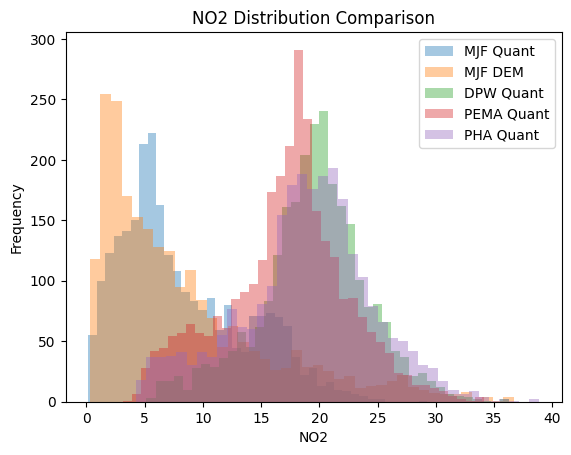

In [193]:
plt.figure()

for df, label in [
    (mjf_quant,"MJF Quant"),
    (mjf_dem,"MJF DEM"),
    (dpw_quant,"DPW Quant"),
    (pema_quant,"PEMA Quant"),
    (pha_quant,"PHA Quant")
]:
    plt.hist(df["no2"], bins=40, alpha=0.4, label=label)

plt.xlabel("NO2")
plt.ylabel("Frequency")
plt.title("NO2 Distribution Comparison")
plt.legend()

plt.show()

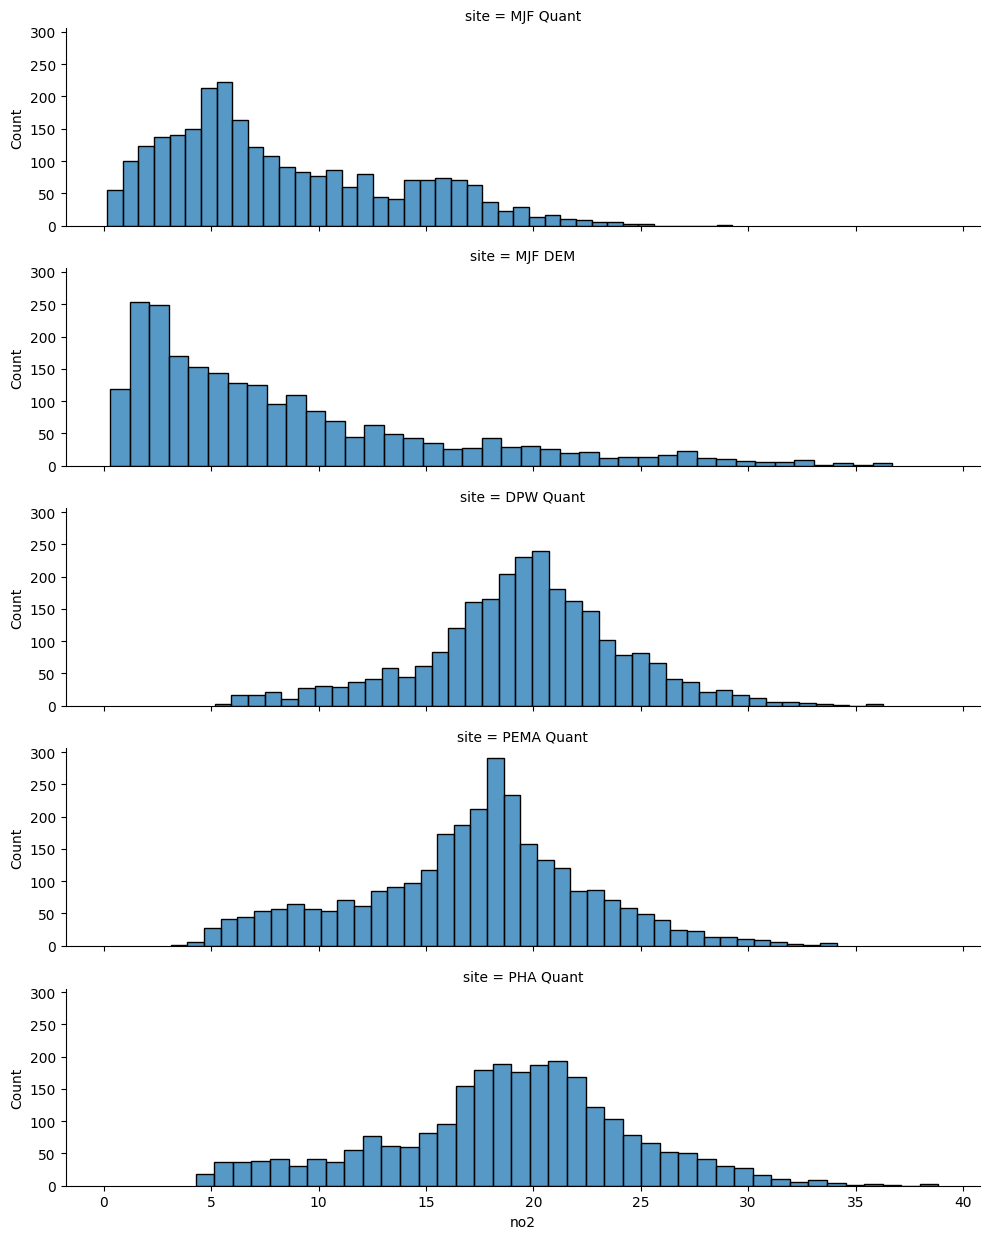

In [194]:
g = sns.FacetGrid(all_data, row="site", height=2.5, aspect=4)
g.map(sns.histplot, "no2", bins=40)

plt.show()

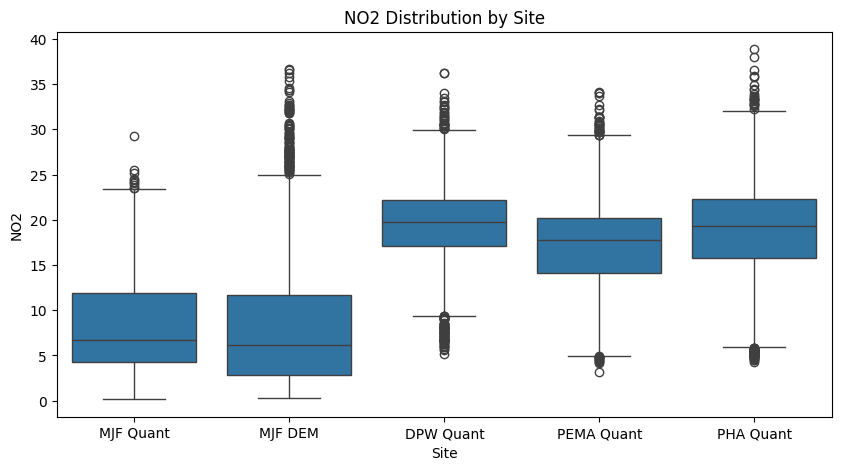

In [196]:
all_data = all_data.reset_index(drop=True)
plt.figure(figsize=(10,5))

sns.boxplot(data=all_data, x="site", y="no2")

plt.title("NO2 Distribution by Site")
plt.xlabel("Site")
plt.ylabel("NO2")

plt.show()